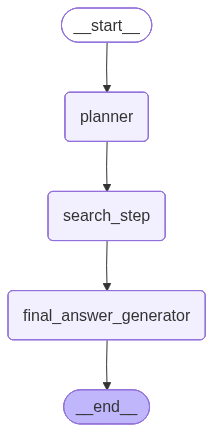


--- Running Research Assistant Graph ---
--- Planning Research ---
Sub-questions Planned: ['What are the primary functionalities and capabilities of LangGraph?', 'What are the key features and components of LCEL?', 'How do LangGraph and LCEL differ in terms of usability, performance, and application areas?']
--- Researching: What are the primary functionalities and capabilities of LangGraph? ---
--- Researching: What are the key features and components of LCEL? ---
--- Researching: How do LangGraph and LCEL differ in terms of usability, performance, and application areas? ---
--- Generating Final Answer ---

--- Final Research Report ---
LangGraph and the LangChain Expression Language (LCEL) are both tools within the LangChain ecosystem, designed to enhance the creation and management of AI applications. However, they cater to different aspects of AI workflow management and have distinct features and applications.

### LangGraph

1. **Core Functionality**: LangGraph is a stateful orch

In [2]:
import os
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated
import operator
import nest_asyncio

# Apply patch for running async in Jupyter
nest_asyncio.apply()

# Core LangGraph components
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

# LLM, tools, messages
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from tavily import TavilyClient

# For displaying the graph image
from IPython.display import Image, display

# Load API keys and set up tracing
load_dotenv()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGSMITH_PROJECT"] = "Intro to LangGraph"

# --- Define Tools ---
@tool
def search_tavily(query: str) -> str:
    """Searches the web for the user's query using Tavily."""
    tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    results = tavily.search(query=query, max_results=3)
    return str(results['results'])

tools = [search_tavily]
tool_node = ToolNode(tools)

# --- Define State ---
class GraphState(TypedDict):
    question: str
    sub_questions: List[str] # Add sub_questions to the state schema
    research_results: Annotated[List[str], operator.add]
    final_answer: str

# --- Define Nodes ---
def plan_research(state: GraphState):
    print("--- Planning Research ---")
    llm = ChatOpenAI(model="gpt-4o")
    prompt = f"""Based on the user's question, identify 2-3 specific sub-questions that need to be researched to provide a comprehensive answer.
    User Question: {state['question']}
    Sub-questions (list format, one per line starting with number and dot, e.g., '1. Question'):"""
    response = llm.invoke(prompt)
    
    # Simple parsing - assumes the response is a numbered list
    sub_questions = [q.split('.', 1)[-1].strip() for q in response.content.split('\n') if q.strip() and '.' in q]
    print(f"Sub-questions Planned: {sub_questions}")
    
    # Ensure we return an empty list if parsing fails
    if not sub_questions:
        print("Warning: Failed to parse sub-questions from planner.")
        
    return {"sub_questions": sub_questions or []} # Return empty list if parsing failed

def execute_search(sub_question: str):
    print(f"--- Researching: {sub_question} ---")
    llm = ChatOpenAI(model="gpt-4o")
    llm_with_tools = llm.bind_tools(tools)
    
    messages = [HumanMessage(content=f"Search the web to answer: {sub_question}")]
    ai_msg = llm_with_tools.invoke(messages)
    
    if ai_msg.tool_calls:
        tool_call = ai_msg.tool_calls[0]
        tool_result = search_tavily.invoke(tool_call['args'])
        return f"Result for '{sub_question}': {tool_result}"
    else:
        return f"Result for '{sub_question}': {ai_msg.content}"

def generate_final_answer(state: GraphState):
    print("--- Generating Final Answer ---")
    llm = ChatOpenAI(model="gpt-4o")
    
    combined_research = "\n\n".join(state.get('research_results', [])) # Use .get() for safety
    prompt = f"""Based on the following research, provide a comprehensive answer to the original question.
    Original Question: {state['question']}
    
    Research Findings:
    {combined_research}
    
    Final Answer:"""
    
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# --- Build the Graph ---
workflow = StateGraph(GraphState)

workflow.add_node("planner", plan_research)
# FIX: Use .get() in the lambda function for safety
workflow.add_node("search_step", lambda state: {"research_results": [execute_search(q) for q in state.get("sub_questions", [])]})
workflow.add_node("final_answer_generator", generate_final_answer)

# Define the edges
workflow.add_edge(START, "planner")
workflow.add_edge("planner", "search_step")
workflow.add_edge("search_step", "final_answer_generator")
workflow.add_edge("final_answer_generator", END)

# Compile the graph
app = workflow.compile()

# --- Display the Graph Image ---
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not draw graph: {e}. Ensure pygraphviz and Pillow are installed.")

# --- Run the Graph ---
print("\n--- Running Research Assistant Graph ---")
inputs = {"question": "Compare the main features of LangGraph and LCEL."}
final_state = app.invoke(inputs)

print("\n--- Final Research Report ---")
# Access final answer safely
print(final_state.get('final_answer', 'No final answer generated.'))